# Customer KPI & Segmentation EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


In [1]:
import importlib
import sys
import os
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

In [2]:
DATA_PATH = '../../data/processed/quality'
output_dir = '../../data/processed/features'

# ถ้ายังไม่มีโฟลเดอร์นี้ ให้สร้างขึ้นมา
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Created directory: {output_dir}")

# === POLARS: Load data with lazy evaluation ===
orders_pl = pl.scan_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior_pl = pl.scan_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train_pl = pl.scan_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products_pl = pl.scan_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles_pl = pl.scan_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments_pl = pl.scan_csv(Path(DATA_PATH) / 'departments_clean.csv')

# Keep pandas dataframes for display/downstream if needed
orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pd.read_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pd.read_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pd.read_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments = pd.read_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

# 1) Customer Segmentation Value Analysis By Reorder Time

แบ่งลูกค้าออกเป็นกลุ่มตามพฤติกรรม แล้วประมาณ **มูลค่าสัมพัทธ์** ของแต่ละกลุ่มผ่าน Value Index

| ขั้นตอน | รายละเอียด |
|---------|-----------|
| 1.1 | สร้าง User Segment (Whales / Regulars / Churned) |
| 1.2 | กำหนด Value Weight ตาม Aisle → คำนวณ Value Index |
| 1.3 | Spending Intensity & Segment Strategy Map |

### 1.1) User Segmentaion

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

In [3]:
start_date = pd.to_datetime("2025-01-01")

# === POLARS: Build main dataframe with joins ===
# 1. Join Orders + Products + Dates + Aisles
order_dates_df_pl = pl.scan_csv('../../data/processed/features/orders_with_dates.csv').with_columns(
    pl.col("order_date").str.to_date()
)

df_pl = (
    orders_pl
    .join(order_products_prior_pl, on="order_id", how="inner")
    .join(order_dates_df_pl, on="order_id", how="left")
    .join(products_pl.select(["product_id", "aisle_id", "product_name"]), on="product_id", how="left")
    .join(aisles_pl.select(["aisle_id", "aisle"]), on="aisle_id", how="left")
    .drop("aisle_id")
    .collect()  # Materialize the data
)

# Convert to pandas for downstream compatible code
df = df_pl.to_pandas()

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

In [4]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
display(segment_summary)

Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20024,51.0,9.33737,0.727273,7.0
1,Regulars,122999,10.0,9.03125,0.431373,12.0
2,Churned,63186,6.0,8.50000,0.341463,31.0


/tmp/ipykernel_263105/2476734674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x="segment", order=segment_summary["segment"], palette=segment_colors)


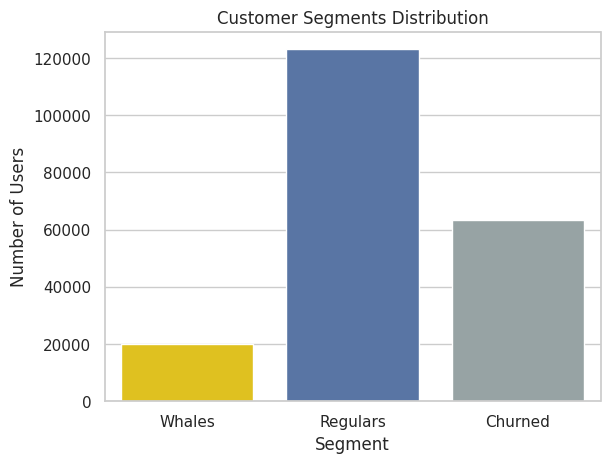

In [5]:
segment_colors = {
    "Whales": "#FFD700",    # สีทอง (High Value)
    "Regulars": "#4C72B0",  # สีฟ้า (Stable)
    "Churned": "#95a5a6"    # สีเทา (Lost)
}

sns.countplot(data=rfm, x="segment", order=segment_summary["segment"], palette=segment_colors)
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.show()

### 💡 Segment Insights

#### 🐋 Whales — High-Value Power Users
> - ลูกค้ากลุ่มนี้มี **loyalty สูงมาก** (reorder ~73%)
> - สั่งซื้อบ่อย (51 orders median) และยัง active ล่าสุด
> - เป็นกลุ่มที่สร้างรายได้หลัก → **ควรรักษาไว้ด้วย loyalty program**

#### 👥 Regulars — Core Mainstream Users
> - เป็นฐานลูกค้าหลัก (~90%) แต่ **reorder ratio ยังต่ำ** (~40%)
> - พฤติกรรมอยู่ระหว่าง ทดลองสินค้าและซื้อซ้ำ
> - มี potential สูงในการ convert ไปเป็น Whales → **ใช้ personalized recommendation**

#### 🔴 Churned — Inactive Users
> - ไม่ได้สั่งซื้อมานานกว่า 30 วัน
> - ควรทำ **win-back campaign** ด้วย incentive หรือ reminder notification

---

### 1.2) Segment Value Contribution

เนื่องจากไม่มีข้อมูลราคาจริง เราจึงสร้าง **Value Index** จาก Aisle-level weight เพื่อประมาณมูลค่าสัมพัทธ์ของแต่ละ order line

**ขั้นตอน:**
1. สำรวจ Aisles ที่มีอยู่ในข้อมูล
2. กำหนด weight สำหรับแต่ละ aisle (ตามช่วงราคาตลาดทั่วไป)
3. คำนวณ `value_index = quantity × value_weight` ต่อ order line

In [6]:
aisles = (
    pd.Series(df["aisle"].dropna().unique(), name="aisle")
    .sort_values()
    .reset_index(drop=True)
)

aisle_counts = (
    df["aisle"]
    .value_counts(dropna=False)
    .rename_axis("aisle")
    .reset_index(name="order_lines")
    .head(20)
)

print(f"Unique aisles: {len(aisles):,}")
display(aisle_counts, title="Aisle frequency (order lines):", n=len(aisle_counts))

Unique aisles: 134


,aisle,order_lines
0,fresh fruits,3642188
1,fresh vegetables,3418021
2,packaged vegetables fruits,1765313
3,yogurt,1452343
4,packaged cheese,979763
5,milk,891015
6,water seltzer sparkling water,841533
7,chips pretzels,722470
8,soy lactosefree,638253
9,bread,584834


#### 📌 Value Weight Map

> **Assumption:** ไม่มีข้อมูลราคาจริง — ใช้ relative weight ตาม aisle category เพื่อประมาณ spending intensity
> Weight สูง = หมวดสินค้าราคาสูง (เช่น alcohol ≈ 3.0×, fresh produce ≈ 1.0×)

| กลุ่ม | ตัวอย่าง Aisle | Weight |
|------|--------------|--------|
| 🟢 Fresh / Low | fresh fruits, vegetables | 1.0× |
| 🟡 Dairy / Bakery | milk, yogurt, bread | 1.4–1.7× |
| 🔴 Meat / Seafood | meat counter, seafood | 2.3–2.7× |
| 🟣 Alcohol / Personal care | wines, spirits, skin care | 2.4–3.8× |

In [7]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5
}

# 2) CREATE VALUE INDEX
# =========================
df["value_weight"] = df["aisle"].map(value_weight_map)
df["value_weight"] = df["value_weight"].fillna(1.5)

df["quantity"] = 1
df["value_index"] = df["quantity"] * df["value_weight"]

df["total_price"] = df["value_index"]

In [8]:
# =========================
# 3) CUSTOMER LEVEL AGG
# =========================
customer_df = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("product_id", "count"),
        total_value_index=("value_index", "sum"),
        avg_item_weight=("value_weight", "mean"),
        median_item_weight=("value_weight", "median"),
        reorder_rate = ("reordered", "mean"),
        
        # ค่ากลางของรสนิยม (Typical Weight)
        
    )
    .reset_index()
)

customer_df["avg_value_per_order"] = (
    customer_df["total_value_index"] / customer_df["total_orders"]
)

customer_df["avg_items_per_order"] = (
    customer_df["total_items"] / customer_df["total_orders"]
)

# =========================
# 4) MERGE WITH RFM SEGMENT
# =========================
customer_df = customer_df.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left"
)

# =========================
# 5) SEGMENT KPI
# =========================
segment_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        total_value=("total_value_index", "sum"),
        avg_value_per_user=("total_value_index", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_items_per_order=("avg_items_per_order", "mean"),
        avg_item_weight = ("avg_item_weight", "mean"),
        median_item_weight = ("avg_item_weight", "median"),
        median_reorder_rate = ("reorder_rate", "median")
    )
    .reset_index()
)

# optional: sort by value
segment_kpi = segment_kpi.sort_values(
    by="total_value", ascending=False
)

In [9]:
segment_analysis = segment_kpi.groupby("segment").describe().T
display(segment_kpi, title="Segment KPI summary:")

,segment,total_users,total_value,avg_value_per_user,avg_orders,avg_items_per_order,avg_item_weight,median_item_weight,median_reorder_rate
1,Regulars,122999,23156206.8,188.263374,12.530671,10.112882,1.479583,1.461538,0.431373
0,Whales,20024,16655655.5,831.784633,56.708750,10.276356,1.452867,1.439414,0.727273
2,Churned,63186,7734943.4,122.415462,8.515779,9.534683,1.494305,1.471978,0.341463


ข้อมูลนี้พิสูจน์ว่ากลยุทธ์ของแอปฯ ควรจะเน้นที่ "การทำให้ลูกค้าหาของเดิมเจอให้เร็วที่สุด" (เช่น ปุ่ม Buy it again) มากกว่าการพยายามแนะนำของใหม่ (Discovery) สำหรับกลุ่ม Whales เพราะหัวใจที่ทำให้เขามาหาเรา 56 ครั้งต่อปี คือ "ความง่ายในการซื้อของเดิม" ครับ

ตัวเลข Reorder 0.72 คือหมัดเด็ดของกลุ่ม Whales เลยครับ Poom มันยืนยันว่าเขา "เสพติด" การซื้อซ้ำกับเราเข้าให้แล้ว!

1. 🟢 Regulars (กลุ่มฐานรากที่แข็งแกร่ง)

    นิยาม: กลุ่มลูกค้าส่วนใหญ่ที่เป็น "กระดูกสันหลัง" ของรายได้

    Key Insight: แม้มูลค่าต่อหัวจะปานกลาง ($188) แต่ด้วยจำนวนคนมหาศาล (1.2 แสนคน) ทำให้กลุ่มนี้สร้าง Total Value สูงที่สุด (23 ล้าน)

    พฤติกรรม: ซื้อของตะกร้าใหญ่พอๆ กับ Whales และเลือกสินค้าที่มีมูลค่า (Value Weight) สูงที่สุดเป็นอันดับสอง

2. 🐋 Whales (กลุ่มแฟนพันธุ์แท้)

    นิยาม: กลุ่ม Super Users ที่มีความภักดีสูงมาก

    Key Insight: ความพิเศษไม่ได้อยู่ที่ "รวยกว่า" หรือ "ซื้อของแพงกว่า" แต่อยู่ที่ "มาบ่อยกว่า" (สั่งเฉลี่ย 56 ครั้ง เทียบกับกลุ่มอื่นที่ 8-12 ครั้ง)

    พฤติกรรม: ใช้บริการเราเป็นส่วนหนึ่งของชีวิตประจำวัน มักซื้อของใช้จำเป็นบ่อยๆ ทำให้ค่าเฉลี่ย Weight สินค้าต่ำกว่ากลุ่มอื่นเล็กน้อย

3. 🔴 Churned (กลุ่มที่หลุดมือไป)

    นิยาม: อดีตลูกค้าที่หยุดการสั่งซื้อ

    Key Insight: เป็นกลุ่มที่น่าเสียดายที่สุด เพราะ Data บ่งบอกว่าคนกลุ่มนี้มี Value Weight ต่อชิ้นสูงที่สุด (1.49) แปลว่าเขามักจะเลือกซื้อของพรีเมียมก่อนที่จะเลิกใช้ไป

    โอกาส: การดึงคนกลุ่มนี้กลับมา (Reactivation) อาจสร้างกำไรต่อหน่วยได้สูงกว่ากลุ่มอื่น

บทสรุปเชิงกลยุทธ์ (Business Recommendations)

    Retention over Premium: ไม่ต้องพยายามยัดเยียดของแพงให้ Whales เพราะเขาซื้อของเหมือนคนปกติ แต่ต้องรักษาความถี่ (Frequency) ให้เขาอยู่กับเรานานที่สุด

    Scale the Regulars: กลยุทธ์ที่ทำเงินได้มากที่สุดคือการเปลี่ยน Regulars บางส่วนให้กลายเป็น Whales (เพิ่มความถี่การซื้อ)

    High-Value Reactivation: ควรเจาะกลุ่ม Churned ด้วยแคมเปญสินค้ากลุ่มพรีเมียม (High Weight) เพราะเป็นกลุ่มที่มีรสนิยมการซื้อของมูลค่าสูงติดตัวอยู่แล้ว

---
### 1.3) Average Items per Order & Segment 

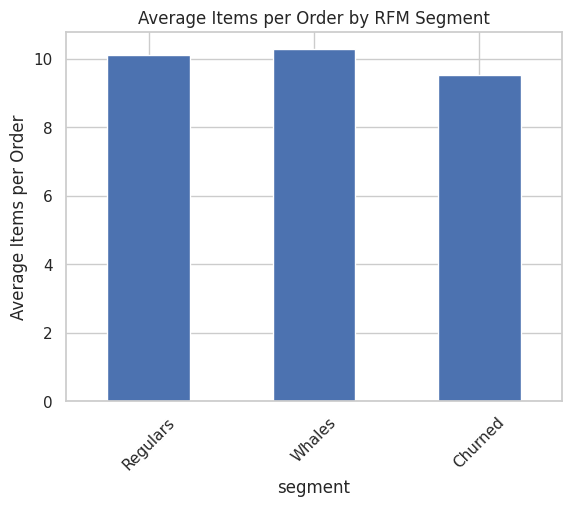

In [10]:
plt.figure()
segment_kpi.set_index("segment")["avg_items_per_order"].plot(kind="bar")
plt.title("Average Items per Order by RFM Segment")
plt.ylabel("Average Items per Order")
plt.xticks(rotation=45)
plt.show()


### 1.3) Total Value Spending Intensity 

วิเคราะห์ **ความเข้มข้นในการใช้จ่ายยอมรวม** ต่อลูกค้าในแต่ละ segment และสร้าง Strategy Map เพื่อเปรียบเทียบ:
- **Volume** (จำนวนลูกค้า) vs **Intensity** (มูลค่าเฉลี่ยต่อคน)
- ช่วยระบุ segment ที่มี ROI สูงสุดสำหรับ marketing investment

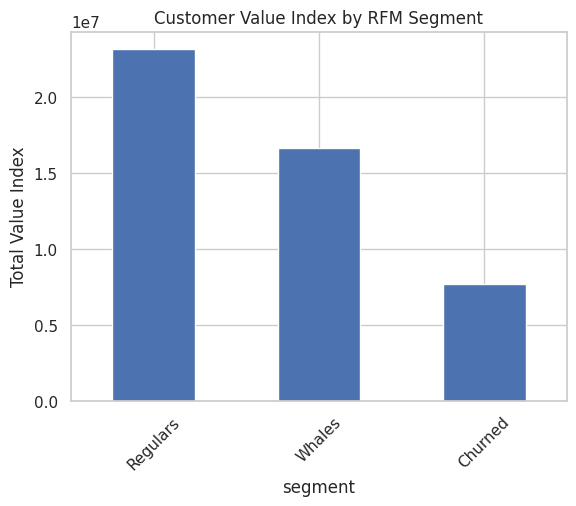

In [11]:
plt.figure()
segment_kpi.set_index("segment")["total_value"].plot(kind="bar")
plt.title("Customer Value Index by RFM Segment")
plt.ylabel("Total Value Index")
plt.xticks(rotation=45)
plt.show()

---

### 1.3) Spending Intensity & Segment Strategy Map

วิเคราะห์ **ความเข้มข้นในการใช้จ่าย** ต่อลูกค้าในแต่ละ segment และสร้าง Strategy Map เพื่อเปรียบเทียบ:
- **Volume** (จำนวนลูกค้า) vs **Intensity** (มูลค่าเฉลี่ยต่อคน)
- ช่วยระบุ segment ที่มี ROI สูงสุดสำหรับ marketing investment

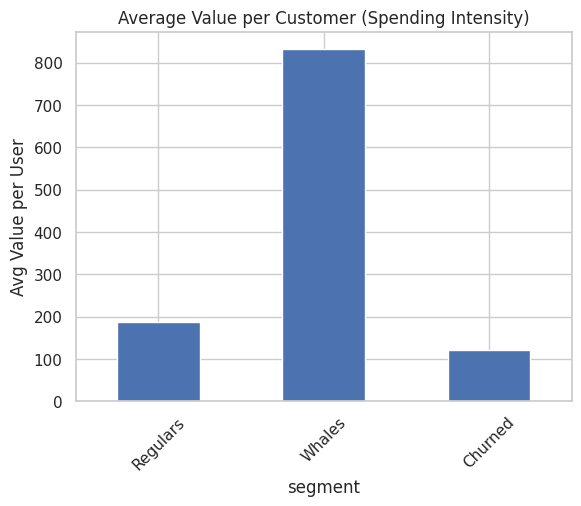

In [12]:
plt.figure()
segment_kpi.set_index("segment")["avg_value_per_user"].plot(kind="bar")
plt.title("Average Value per Customer (Spending Intensity)")
plt.ylabel("Avg Value per User")
plt.xticks(rotation=45)
plt.show()

---

### 1.3) Summary Average Value each Segment


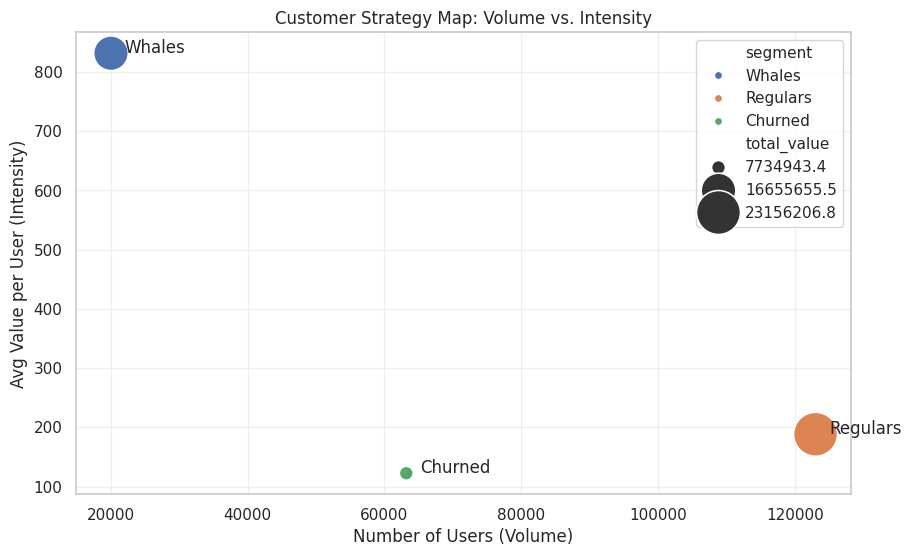

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=segment_kpi,
    x="total_users",        # จำนวนคน (Volume)
    y="avg_value_per_user", # ยอดต่อหัว (Intensity)
    size="total_value",     # ขนาดจุดตามรายได้รวม (Impact)
    hue="segment",
    sizes=(100, 1000)
)

# ใส่ Label กำกับแต่ละจุดให้ชัดๆ กันพลาด
for i in range(segment_kpi.shape[0]):
    plt.text(
        segment_kpi.total_users.iloc[i]+2000, 
        segment_kpi.avg_value_per_user.iloc[i], 
        segment_kpi.segment.iloc[i]
    )

plt.title("Customer Strategy Map: Volume vs. Intensity")
plt.xlabel("Number of Users (Volume)")
plt.ylabel("Avg Value per User (Intensity)")
plt.grid(True, alpha=0.3)
plt.show()

## Customer Taste Stratification by Value Weigh

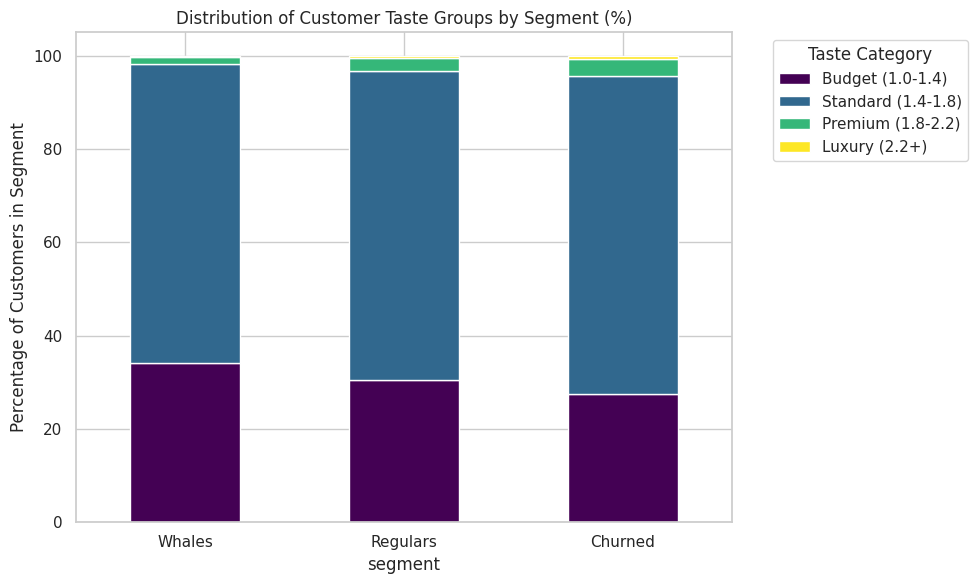

In [14]:
# 1. แบ่งช่วงรสนิยม (Value Weight) เป็นกลุ่มๆ
bins = [1.0, 1.4, 1.8, 2.2, 3.8]
labels = ['Budget (1.0-1.4)', 'Standard (1.4-1.8)', 'Premium (1.8-2.2)', 'Luxury (2.2+)']

# 2. สร้างคอลัมน์ใหม่ใน customer_df เพื่อระบุกลุ่มรสนิยม
customer_df['taste_group'] = pd.cut(customer_df['avg_item_weight'], bins=bins, labels=labels)

# 3. คำนวณสัดส่วน (Normalized) จากกลุ่มที่เราจัดไว้แล้ว
# คราวนี้จะมีแค่ 4 คอลัมน์ตาม labels ของเรา
weight_dist = customer_df.groupby(['segment', 'taste_group'], observed=False).size().unstack(fill_value=0)
weight_dist_pct = weight_dist.div(weight_dist.sum(axis=1), axis=0) * 100

# 4. พลอตดูรสนิยม
weight_dist_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Distribution of Customer Taste Groups by Segment (%)")
plt.ylabel("Percentage of Customers in Segment")
plt.legend(title="Taste Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
Customer_Taste_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        avg_item_weight = ("avg_item_weight", "mean"),
        median_item_weight = ("avg_item_weight", "median"),
        median_reorder_rate = ("reorder_rate", "median"),
        max_taste_weight = ("avg_item_weight", "max"),
    )
    .reset_index()
)

display(Customer_Taste_kpi, title="Customer Taste KPI by Segment:")

,segment,total_users,avg_item_weight,median_item_weight,median_reorder_rate,max_taste_weight
0,Whales,20024,1.452867,1.439414,0.727273,3.187931
1,Regulars,122999,1.479583,1.461538,0.431373,3.800000
2,Churned,63186,1.494305,1.471978,0.341463,3.650000


Whales คือกลุ่ม "ของกินของใช้" (Budget/Standard):

    สังเกตสีม่วง (Budget) และสีน้ำเงิน (Standard) ในแท่งของ Whales จะมีสัดส่วนรวมกันสูงกว่ากลุ่มอื่นเล็กน้อย

    นั่นแปลว่าพฤติกรรมหลักของ Whales คือการใช้แอปฯ เพื่อซื้อ Essentials (ของใช้จำเป็นในชีวิตประจำวัน) ซึ่งมักจะมีมูลค่าต่อน้ำหนักไม่สูงมาก แต่ต้องใช้ตลอด

Regulars & Churned คือกลุ่ม "เลือกสรร" (Premium/Luxury):

    ดูที่สีเขียว (Premium) และสีเหลือง (Luxury) บนยอดแท่งของ Churned และ Regulars นะครับ จะเห็นว่ามันหนากว่ากลุ่ม Whales ชัดเจน

    นี่คือการพิสูจน์สมมติฐานที่คุณตั้งไว้เลยครับว่า คนกลุ่มนี้เวลาจะซื้อที เขาเลือกของที่มีมูลค่าสูงกว่า หรือของเฉพาะเจาะจงมากกว่า

"Loyalty is driven by Convenience, not Luxury"

จากการวิเคราะห์ Customer Taste KPI พบว่ากลุ่มลูกค้าที่ทรงคุณค่าที่สุด (Whales) ไม่ใช่กลุ่มที่มองหาสินค้าพรีเมียม แต่เป็นกลุ่มที่เน้นสินค้าอุปโภคบริโภคพื้นฐาน (Budget/Standard) และมีอัตราการซื้อซ้ำ (Reorder Rate) สูงถึง 72% ในขณะที่กลุ่ม Churned และ Regulars มีแนวโน้มเลือกซื้อสินค้าที่มีมูลค่าต่อน้ำหนักสูงกว่า (Specific/Premium items) แต่กลับมีความถี่ในการใช้งานและการซื้อซ้ำที่ต่ำกว่าอย่างเห็นได้ชัด

## Customer Lifetime Value (CLV)

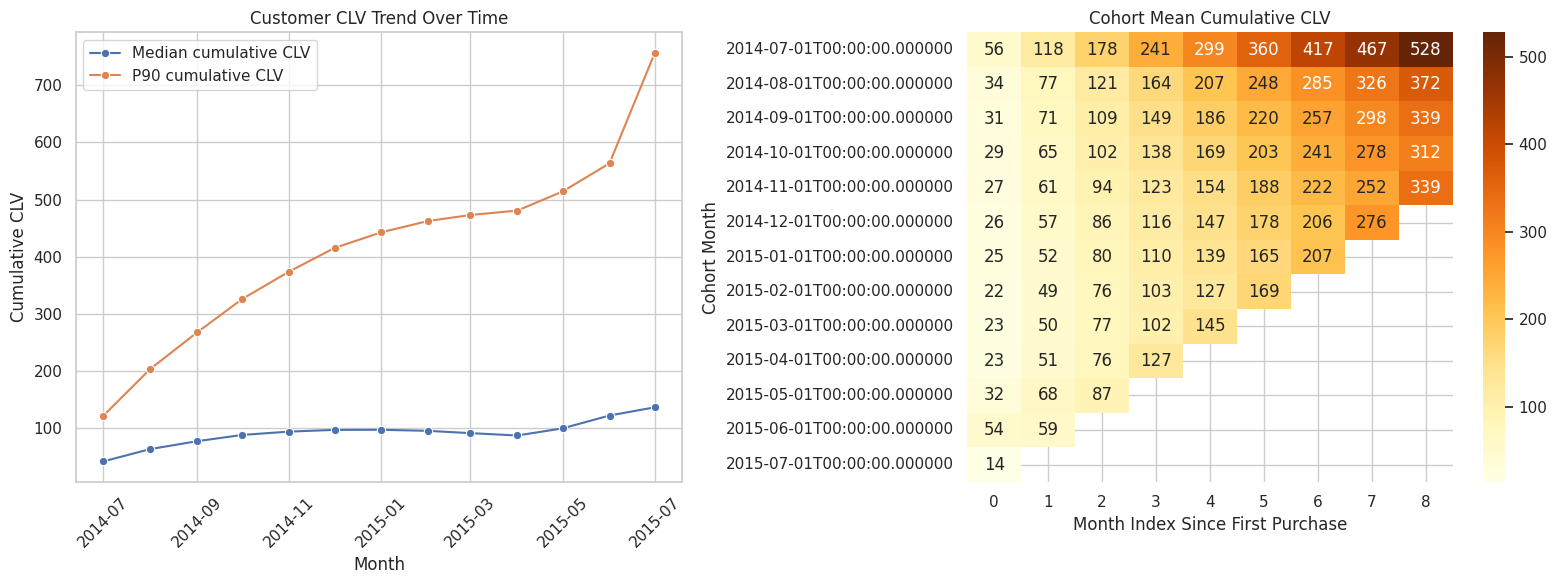

,total_orders,total_spend,avg_order_value,lifetime_days,orders_per_month,estimated_monthly_clv
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,15.590367,230.575803,14.675987,157.222595,2.826441,41.148269
std,16.654774,298.746797,8.759274,103.187341,1.712225,34.834455
min,3.000000,3.000000,1.000000,1.000000,1.111111,1.263830
25%,5.000000,57.700000,8.488889,67.000000,1.750000,18.966102
50%,9.000000,122.700000,13.070588,133.000000,2.357143,32.179856
75%,19.000000,276.200000,19.012500,238.000000,3.312883,52.600000
max,99.000000,5525.600000,107.250000,366.000000,99.000000,1805.357143


,order_month,active_customers,avg_monthly_spend,median_cumulative_clv,p90_cumulative_clv
7,2015-02-01,120843,32.422491,95.7,462.70
8,2015-03-01,148737,34.920214,91.7,473.10
9,2015-04-01,181852,35.021045,87.6,480.90
10,2015-05-01,201055,35.471818,100.1,514.30
11,2015-06-01,206203,32.967759,122.5,563.50
12,2015-07-01,3319,14.159476,136.9,756.82


In [16]:
# --- Customer Lifetime Value (CLV) trends ---
CLV_FREQ = "M"  # monthly trend
MAX_MONTH_INDEX = 8  # keep cohort chart readable

# Build order-level value first to avoid line-level double counting in CLV.
# Use df (pandas) which has value_weight and total_price computed
order_value = (
    df.groupby(["user_id", "order_id", "order_date"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Customer-level CLV profile
customer_clv = (
    order_value.groupby("user_id", observed=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
    )
    .reset_index()
)

customer_clv["lifetime_days"] = (
    customer_clv["last_order_date"] - customer_clv["first_order_date"]
).dt.days + 1
customer_clv["lifetime_months"] = np.maximum(customer_clv["lifetime_days"] / 30.0, 1)
customer_clv["orders_per_month"] = customer_clv["total_orders"] / customer_clv["lifetime_months"]
customer_clv["estimated_monthly_clv"] = customer_clv["avg_order_value"] * customer_clv["orders_per_month"]

# 2) Monthly trend of cumulative CLV per customer
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

clv_trend = (
    customer_monthly.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        avg_monthly_spend=("monthly_spend", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
        p90_cumulative_clv=("cumulative_clv", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 3) Cohort CLV progression (by first purchase month)
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    cohort_base["order_month"].dt.to_period(CLV_FREQ).astype(int)
    - cohort_base["cohort_month"].dt.to_period(CLV_FREQ).astype(int)
)

cohort_clv = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)

cohort_clv_progress = (
    cohort_clv[cohort_clv["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        customers=("user_id", "nunique"),
        mean_cumulative_clv=("cumulative_clv", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
)

cohort_clv_pivot = cohort_clv_progress.pivot(
    index="cohort_month",
    columns="month_index",
    values="mean_cumulative_clv",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    marker="o",
    label="Median cumulative CLV",
    ax=axes[0],
)
sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="p90_cumulative_clv",
    marker="o",
    label="P90 cumulative CLV",
    ax=axes[0],
)
axes[0].set_title("Customer CLV Trend Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cohort_clv_pivot, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Cohort Mean Cumulative CLV")
axes[1].set_xlabel("Month Index Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

display(
    customer_clv[[
        "total_orders",
        "total_spend",
        "avg_order_value",
        "lifetime_days",
        "orders_per_month",
        "estimated_monthly_clv",
    ]].describe(),
    title="Customer CLV profile summary:",
)
display(clv_trend.tail(6), title="Latest CLV trend snapshot:")

if SHOW_VERBOSE_TABLES:
    display(cohort_clv_progress.head(20), title="Cohort CLV progression sample:")

1. กราฟซ้าย: Cumulative CLV Trend (เส้นสะสม)

กราฟนี้บอกเราว่า "เมื่อเวลาผ่านไป ลูกค้า 1 คนทำเงินให้เราสะสมเพิ่มขึ้นเท่าไหร่"

    เส้นสีส้ม (P90 - Top 10%): คือกลุ่มตัวท็อป (เทียบได้กับกลุ่ม Whales ของคุณ) จะเห็นว่ากราฟพุ่งทะยานขึ้นไปถึง 500+ หมายความว่าลูกค้าเกรด A ยิ่งอยู่นาน ยิ่งจ่ายหนักขึ้นเรื่อยๆ แบบก้าวกระโดด

    เส้นสีน้ำเงิน (Median - ลูกค้าทั่วไป): คือลูกค้าส่วนใหญ่ (เทียบได้กับกลุ่ม Regulars) มูลค่าสะสมจะโตขึ้นแบบช้าๆ เรียบๆ อยู่ที่ประมาณ 100

    Insight: ช่องว่าง (Gap) ระหว่างเส้นสีส้มกับน้ำเงินที่กว้างขึ้นเรื่อยๆ บอกเราว่า "กำไรส่วนใหญ่ของบริษัทฝากไว้กับลูกค้าแค่ไม่กี่คน (Whales)" การรักษาคนกลุ่มนี้ 1 คน มีค่าเท่ากับการหาคนทั่วไปเพิ่ม 5 คนครับ

2. กราฟขวา: Cohort Mean Cumulative CLV (ตารางความร้อน)

ตารางนี้เจาะลึกตาม "เดือนที่ลูกค้าเริ่มซื้อครั้งแรก" (Cohort Month) เพื่อดูว่าลูกค้าแต่ละรุ่นมีความ "เปย์" ต่างกันไหม

    ตัวเลขในช่อง: คือ "ค่าเฉลี่ยเงินสะสม" ที่ลูกค้าในรุ่นนั้นจ่ายให้เรา เมื่อเวลาผ่านไป (Month Index)

        ตัวอย่าง: รุ่น 2014-07 (แถวแรกสุด) เดือนที่ 0 จ่าย 39 พอผ่านไป 8 เดือน (ช่องสุดท้ายขวา) จ่ายสะสมรวมเป็น 362

    สีที่เข้มขึ้น (สีน้ำตาล): หมายถึงยอดเงินสะสมที่มากขึ้นตามเวลา ซึ่งเป็นเรื่องปกติ

    จุดที่ต้องสังเกต (Professional Insight):

        ถ้าคุณมองไล่ลงมาตามแนวตั้ง (Month Index เดียวกัน) จะเห็นว่า รุ่นหลังๆ (แถวล่างๆ) เริ่มต้นด้วยตัวเลขที่น้อยลง (เช่น 39 -> 23 -> 21 -> 15)

        ความหมาย: ลูกค้าที่เพิ่งหามาได้ใหม่ๆ มีคุณภาพ (กำลังซื้อ) ต่ำกว่าลูกค้ากลุ่มแรกๆ ที่เราเคยหาได้ นี่คือสัญญาณที่บอกว่า "เราเริ่มหาลูกค้าใหม่ที่เปย์หนักเท่าเดิมไม่ได้แล้ว" หรือ "การแข่งขันในตลาดเริ่มสูงขึ้น"

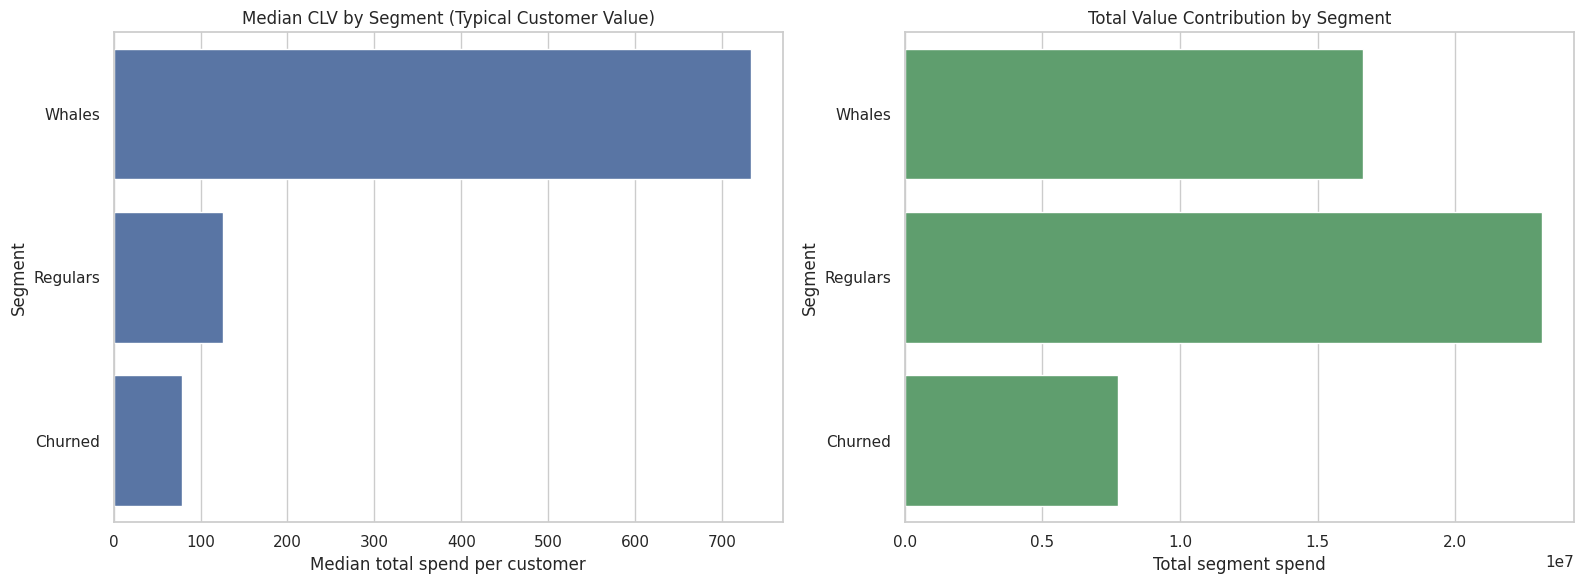

,segment,customers,median_total_spend,mean_total_spend,median_avg_order_value,median_orders_per_month,median_estimated_monthly_clv,total_segment_spend,segment_share_of_spend,median_latest_cumulative_clv
0,Whales,20024,733.45,831.784633,13.475916,4.692737,68.273658,16655655.5,0.350300,733.45
1,Regulars,122999,126.20,188.263374,13.280000,2.424242,32.673387,23156206.8,0.487019,126.20
2,Churned,63186,78.50,122.415462,12.531699,1.895911,25.196132,7734943.4,0.162681,78.50


Top segment by median customer value: Whales (median_total_spend=733.45)
Top segment by total business contribution: Regulars (total_segment_spend=23,156,206.80, share=48.70%)


In [17]:
# --- CLV by segment (median-focused) ---
# Why median: robust to extreme spenders and better reflects a "typical" customer in each segment.

if "segment" not in rfm.columns:
    raise ValueError("`rfm` with `segment` column is required for segment-level CLV analysis.")

# Join customer CLV profile with existing RFM segment labels.
segment_clv_base = customer_clv.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_clv_base["segment"] = segment_clv_base["segment"].fillna("Unknown")

segment_clv_summary = (
    segment_clv_base.groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        median_total_spend=("total_spend", "median"),
        mean_total_spend=("total_spend", "mean"),
        median_avg_order_value=("avg_order_value", "median"),
        median_orders_per_month=("orders_per_month", "median"),
        median_estimated_monthly_clv=("estimated_monthly_clv", "median"),
        total_segment_spend=("total_spend", "sum"),
    )
    .reset_index()
)

segment_clv_summary["segment_share_of_spend"] = (
    segment_clv_summary["total_segment_spend"]
    / segment_clv_summary["total_segment_spend"].sum()
)

segment_clv_summary = segment_clv_summary.sort_values(
    ["median_total_spend", "total_segment_spend"],
    ascending=[False, False],
).reset_index(drop=True)

# Latest cumulative CLV per customer (for an alternative median view).
latest_customer_clv = (
    customer_monthly.sort_values(["user_id", "order_month"])
    .groupby("user_id", observed=False)
    .tail(1)[["user_id", "cumulative_clv"]]
)

segment_latest_median = (
    latest_customer_clv.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(median_latest_cumulative_clv=("cumulative_clv", "median"))
    .reset_index()
)

segment_clv_summary = segment_clv_summary.merge(
    segment_latest_median,
    on="segment",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=segment_clv_summary.sort_values("median_total_spend", ascending=False),
    x="median_total_spend",
    y="segment",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Median CLV by Segment (Typical Customer Value)")
axes[0].set_xlabel("Median total spend per customer")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=segment_clv_summary.sort_values("total_segment_spend", ascending=False),
    x="total_segment_spend",
    y="segment",
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title("Total Value Contribution by Segment")
axes[1].set_xlabel("Total segment spend")
axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

display(segment_clv_summary, title="Segment CLV summary:")

top_median_segment = segment_clv_summary.iloc[0]
top_total_segment = segment_clv_summary.sort_values("total_segment_spend", ascending=False).iloc[0]

print(
    f"Top segment by median customer value: {top_median_segment['segment']} "
    f"(median_total_spend={top_median_segment['median_total_spend']:,.2f})"
)
print(
    f"Top segment by total business contribution: {top_total_segment['segment']} "
    f"(total_segment_spend={top_total_segment['total_segment_spend']:,.2f}, "
    f"share={top_total_segment['segment_share_of_spend']:.2%})"
)

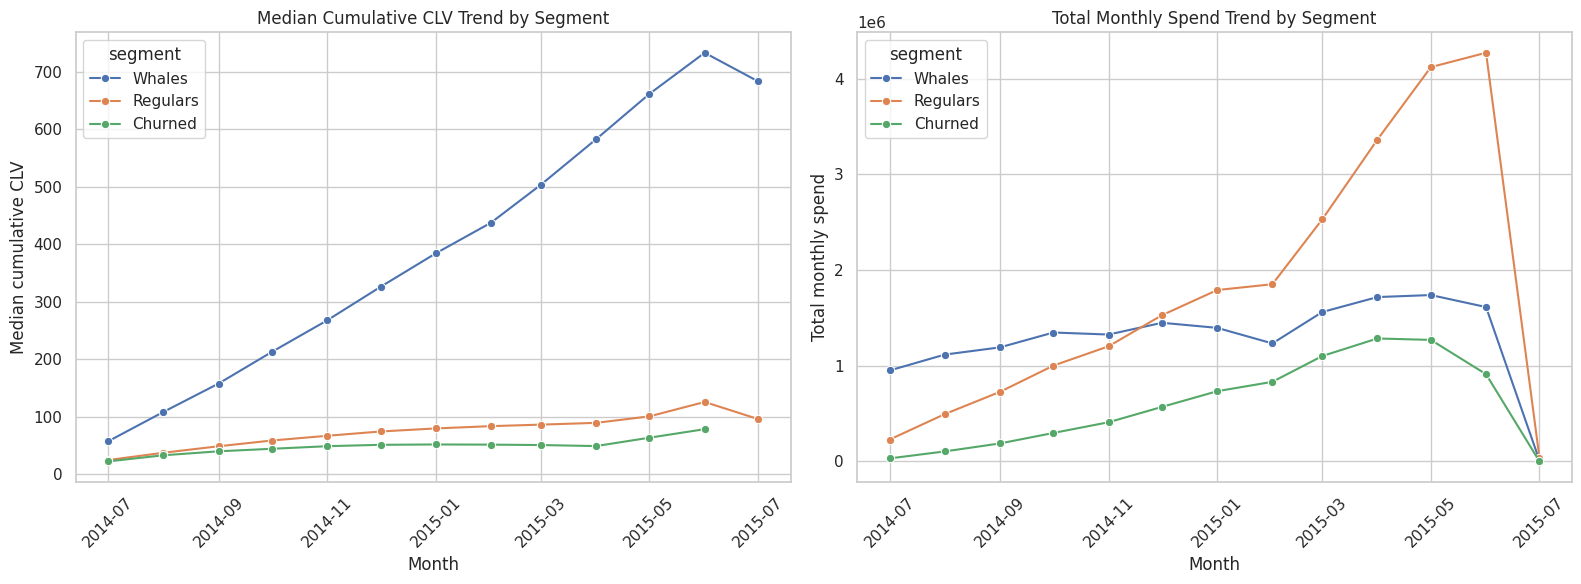

,order_month,segment,active_customers,total_monthly_spend,median_monthly_spend,median_cumulative_clv
27,2015-04-01,Whales,20013,1718246.0,73.30,582.80
28,2015-04-01,Regulars,101841,3365061.6,22.90,89.50
29,2015-04-01,Churned,59998,1285339.4,15.20,49.10
30,2015-05-01,Whales,20021,1739227.4,73.00,661.80
31,2015-05-01,Regulars,117853,4122329.0,24.50,100.80
32,2015-05-01,Churned,63181,1270229.9,14.40,63.70
33,2015-06-01,Whales,20024,1613684.0,66.25,733.25
34,2015-06-01,Regulars,122993,4272508.8,24.80,125.80
35,2015-06-01,Churned,63186,911858.1,11.60,78.50
36,2015-07-01,Whales,690,9920.4,10.65,683.50


,segment_a,segment_b,n_a,n_b,median_a,median_b,median_diff_a_minus_b,p_value,q_value_bh,significant_5pct
0,Churned,Regulars,63186,122999,78.5,126.20,-47.70,0.0005,0.0005,True
1,Churned,Whales,63186,20024,78.5,733.45,-654.95,0.0005,0.0005,True
2,Regulars,Whales,122999,20024,126.2,733.45,-607.25,0.0005,0.0005,True


In [18]:
# --- Segment CLV trend over time + median significance checks ---
SEGMENT_CLV_TEST_PERMUTATIONS = 2000
RANDOM_SEED = 42

segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")


def permutation_test_median_diff(a, b, n_permutations=2000, seed=42):
    """Two-sided permutation test for median difference."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    observed = np.median(a) - np.median(b)
    combined = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    extreme = 0
    for _ in range(n_permutations):
        permuted = rng.permutation(combined)
        diff = np.median(permuted[:n_a]) - np.median(permuted[n_a:])
        if abs(diff) >= abs(observed):
            extreme += 1

    p_value = (extreme + 1) / (n_permutations + 1)
    return observed, p_value


def benjamini_hochberg(p_values):
    """Return BH-adjusted q-values in original order."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked_p[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    q = np.clip(q, 0, 1)
    q_original_order = np.empty(n, dtype=float)
    q_original_order[order] = q
    return q_original_order


segment_spend_for_test = segment_clv_base[["segment", "total_spend"]].dropna().copy()
segments = sorted(segment_spend_for_test["segment"].unique())

pairwise_results = []
for i in range(len(segments)):
    for j in range(i + 1, len(segments)):
        seg_a = segments[i]
        seg_b = segments[j]

        spend_a = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_a,
            "total_spend",
        ]
        spend_b = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_b,
            "total_spend",
        ]

        median_diff, p_value = permutation_test_median_diff(
            spend_a,
            spend_b,
            n_permutations=SEGMENT_CLV_TEST_PERMUTATIONS,
            seed=RANDOM_SEED,
        )

        pairwise_results.append(
            {
                "segment_a": seg_a,
                "segment_b": seg_b,
                "n_a": int(spend_a.shape[0]),
                "n_b": int(spend_b.shape[0]),
                "median_a": float(np.median(spend_a)),
                "median_b": float(np.median(spend_b)),
                "median_diff_a_minus_b": float(median_diff),
                "p_value": float(p_value),
            }
        )

pairwise_median_test = pd.DataFrame(pairwise_results).sort_values("p_value").reset_index(drop=True)
pairwise_median_test["q_value_bh"] = benjamini_hochberg(pairwise_median_test["p_value"].values)
pairwise_median_test["significant_5pct"] = pairwise_median_test["q_value_bh"] < 0.05

display(pairwise_median_test, title="Pairwise median CLV comparison:")

### 📊 สรุปเชิง Insight

### 🐋 กลุ่ม Whale
- มีมูลค่าต่อคนสูงมาก (High value per user)
- ซื้อบ่อย / ปริมาณต่อครั้งสูง → คุณภาพเชิง “ความเข้มข้น” ดีมาก
- แต่มี “จำนวนน้อย” → Contribution รวมยังจำกัด

### 👥 กลุ่ม Regular
- มูลค่าต่อคนต่ำกว่า Whale
- แต่มี “จำนวนลูกค้ามาก”
- ทำให้ **รายได้รวม (Total Revenue Contribution)** สูงกว่า

---

### 🔥 Executive Summary
แม้ลูกค้ากลุ่ม Whale จะสร้างมูลค่าต่อคนสูงและมีพฤติกรรมการซื้อที่เข้มข้น  
แต่เนื่องจากมีจำนวนจำกัด ทำให้รายได้รวมยังน้อยกว่ากลุ่ม Regular  
ซึ่งมีจำนวนมากและสามารถสร้างรายได้รวมได้สูงกว่าในภาพรวม

# 2) Customer Segmentation Preference

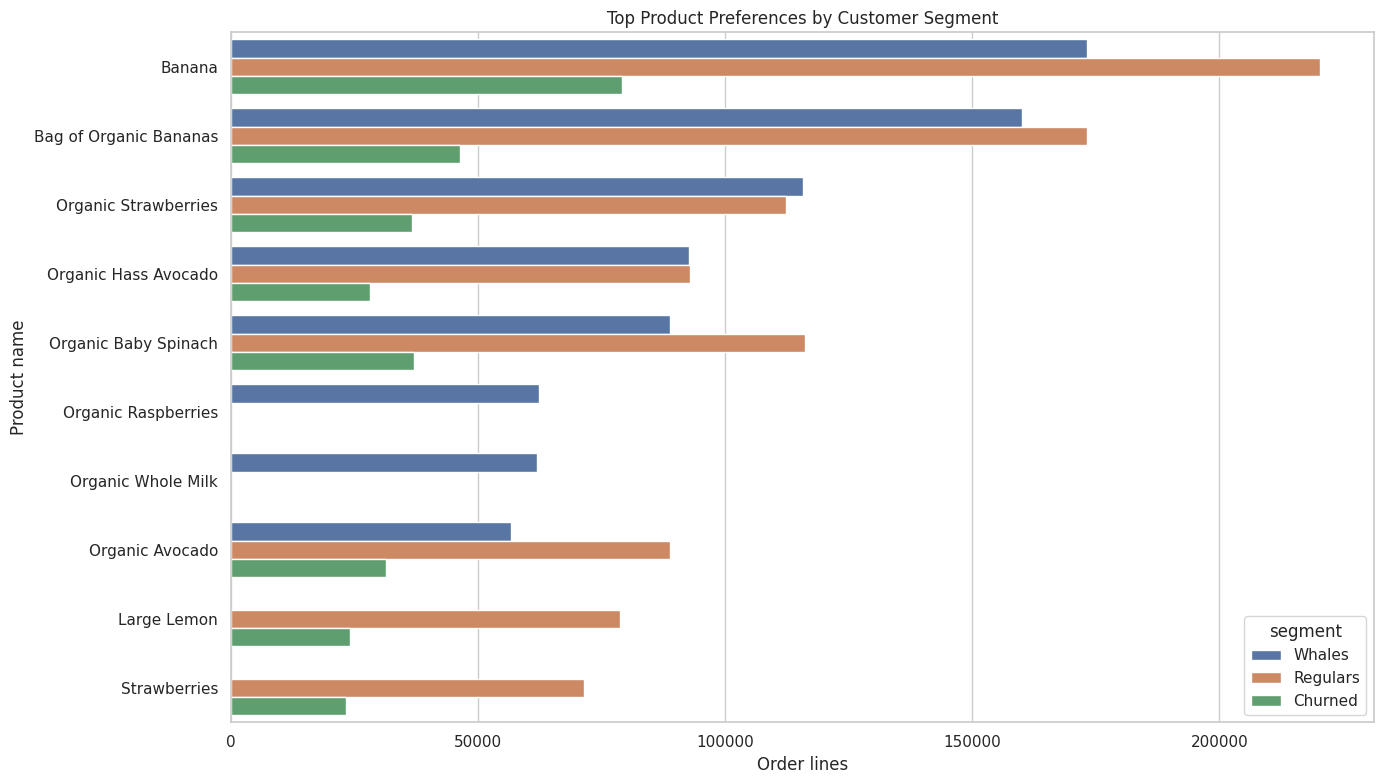

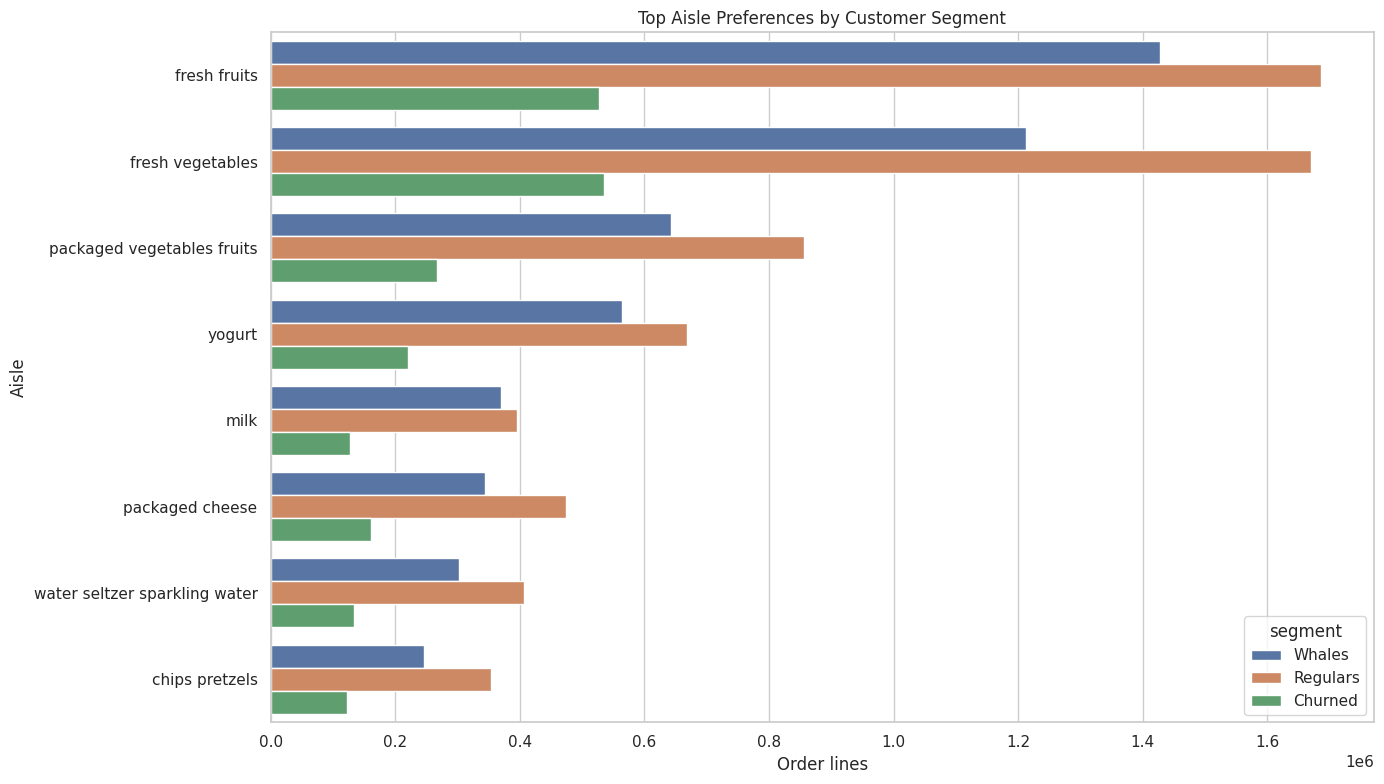

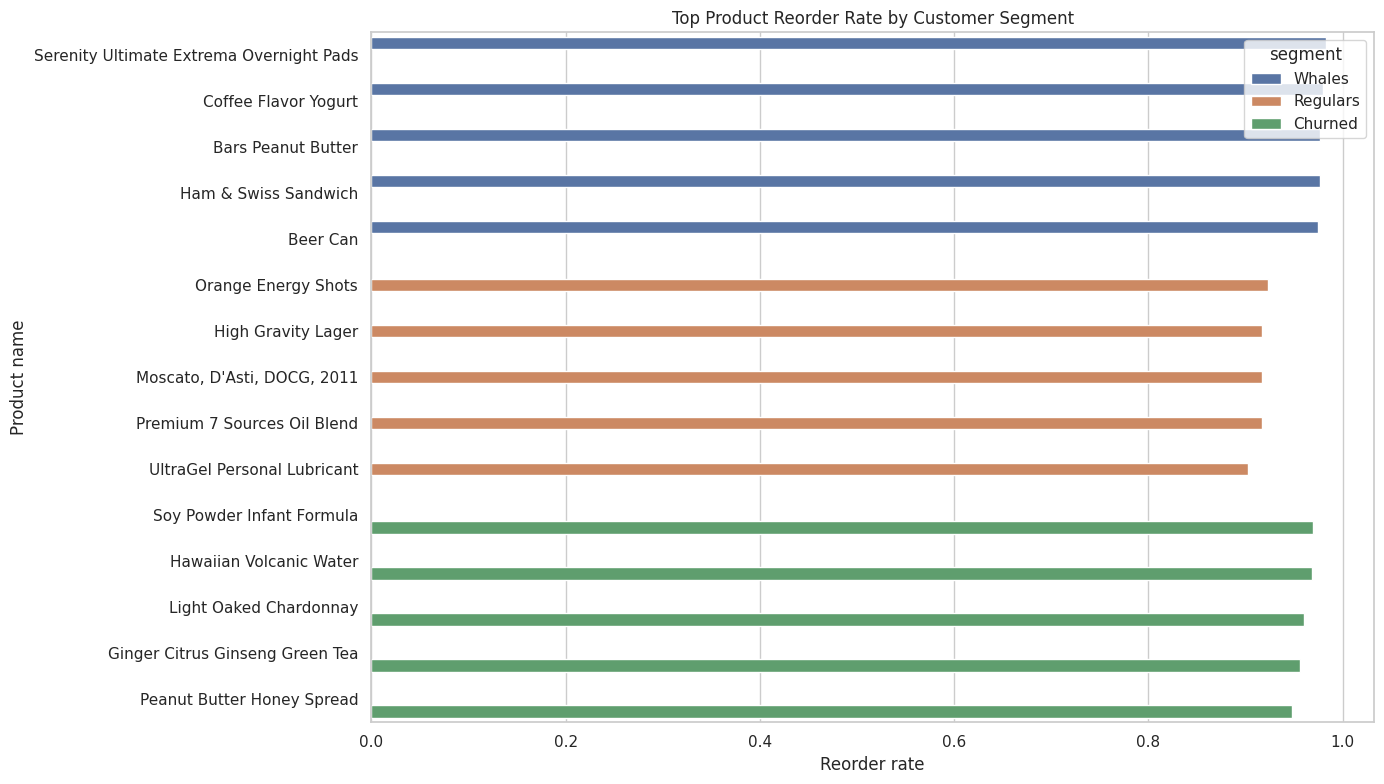

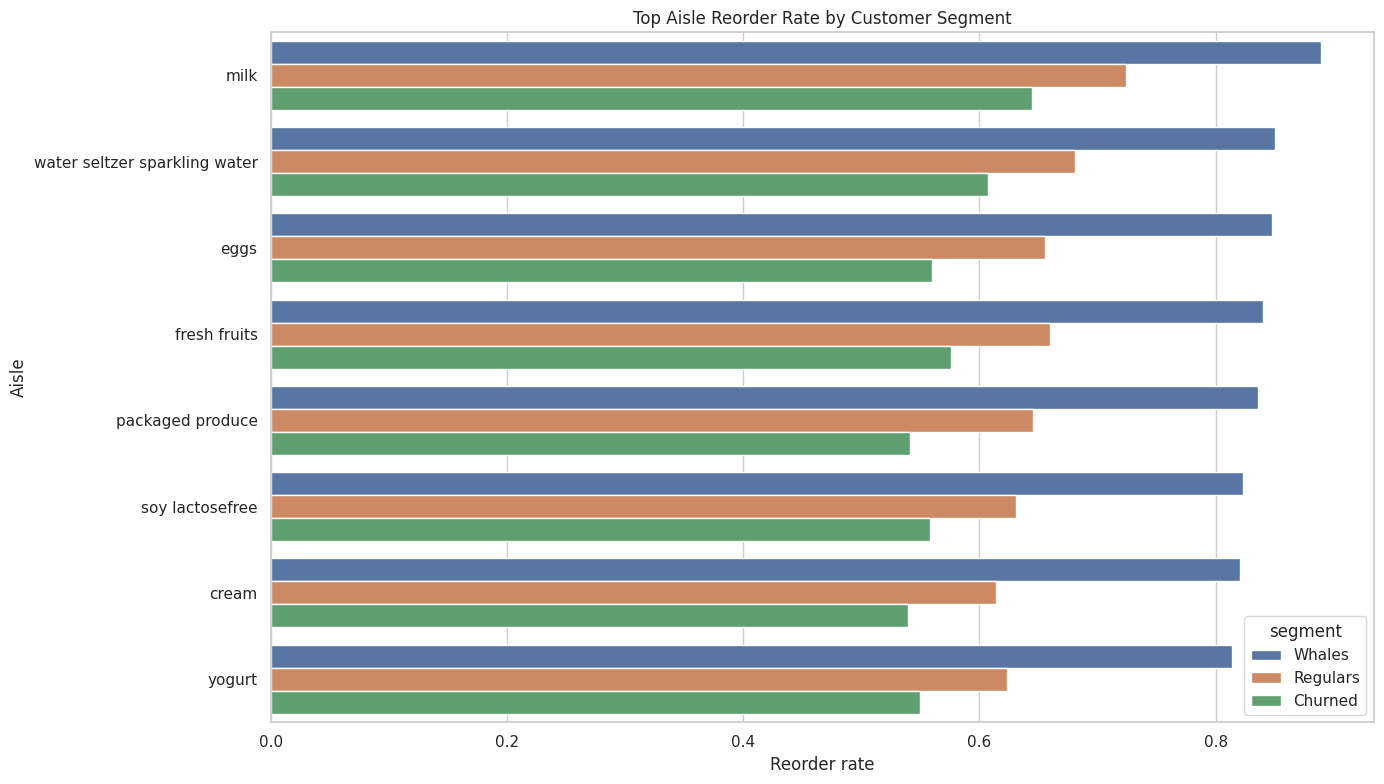

In [19]:
segment_txn = df.copy()

if "segment" not in segment_txn.columns:
    segment_txn = segment_txn.merge(
        rfm[["user_id", "segment"]].drop_duplicates(),
        on="user_id",
        how="left",
    )

segment_txn = segment_txn.dropna(subset=["segment"]).copy()

segment_product_pref = (
    segment_txn.dropna(subset=["product_name"])
    .groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

segment_product_pref["share"] = (
    segment_product_pref["order_lines"]
    / segment_product_pref.groupby("segment", observed=False)["order_lines"].transform("sum")
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.dropna(subset=["product_name"])
    .groupby(["segment", "product_name"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_aisle_by_segment = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .query("order_lines >= 50")   # 👈 กัน noise
    .reset_index()
)

top_reordered_aisle_by_segment = (
    top_reordered_aisle_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(8)   # 👈 เอาแค่ top 8
)


top_reordered_by_segment = (
    top_reordered_by_segment.sort_values(
        ["segment", "reorder_rate", "order_lines", "product_name"],
        ascending=[True, False, False, True],
    )
    .groupby("segment", observed=False)
    .head(5)
    .reset_index(drop=True)
)

#Visualize Top Product Preferences by Customer Segment
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

#Visualize Top Aisle Preferences by Customer Segment
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

#Visualize Top Product Reorder Rate by Customer Segment
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Reorder Rate by Customer Segment")
plt.xlabel("Reorder rate")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

#Visualize Top Aisle Reorder Rate by Customer Segment
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_reordered_aisle_by_segment,
    x="reorder_rate",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Reorder Rate by Customer Segment")
plt.xlabel("Reorder rate")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()


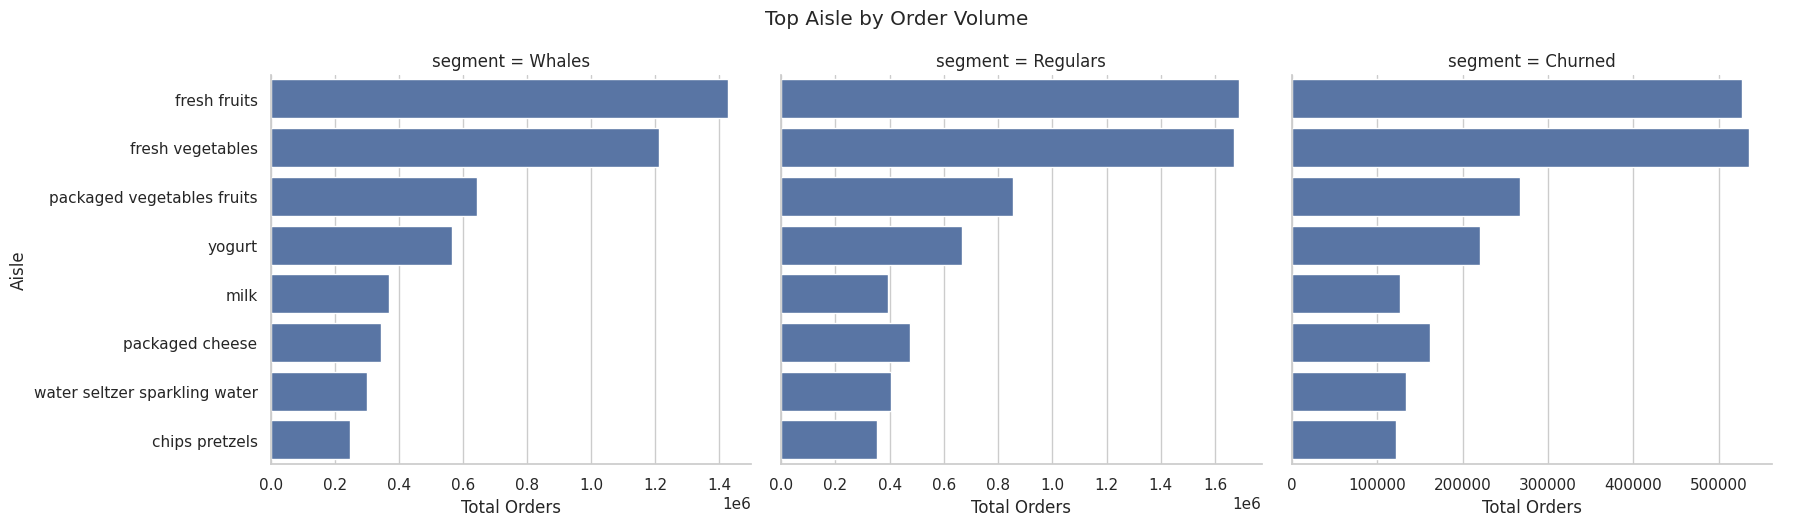

In [20]:
segment_aisle_value = (
    segment_txn
    .groupby(["segment", "aisle"])
    .agg(
        total_orders=("product_id", "count"),
        avg_reorder=("reordered", "mean"),
    )
    .reset_index()
)

top_aisle = (
    segment_aisle_value
    .sort_values(["segment", "total_orders"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(8)
)

g = sns.catplot(
    data=top_aisle,
    x="total_orders",
    y="aisle",
    col="segment",
    kind="bar",
    height=5,
    aspect=1.2,
    sharex=False,
)

g.set_axis_labels("Total Orders", "Aisle")
g.fig.suptitle("Top Aisle by Order Volume", y=1.05)
plt.show()


# 3) Customer Segmentation Daily Time Behavior

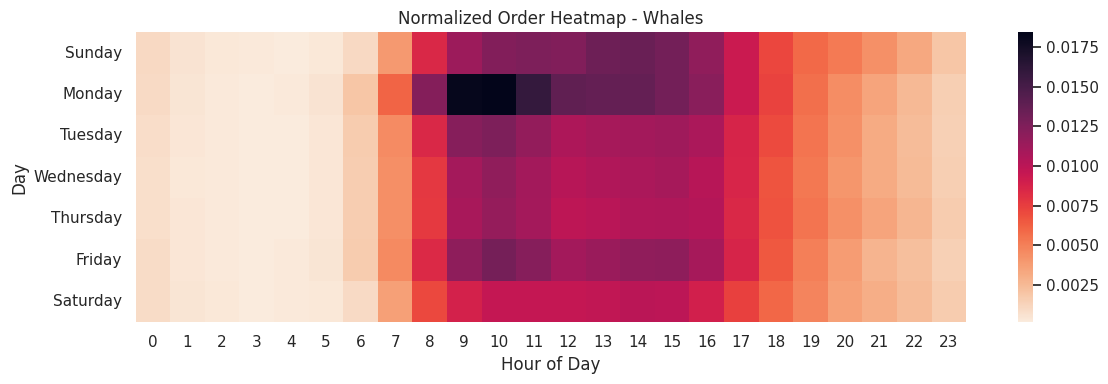

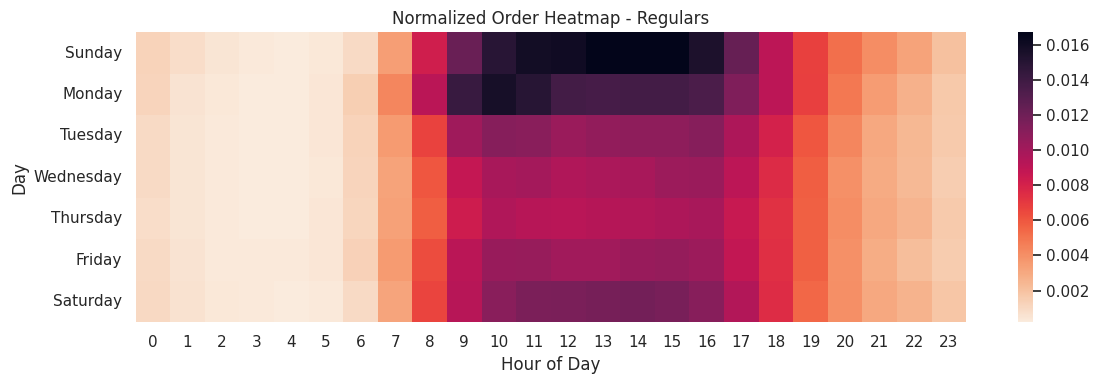

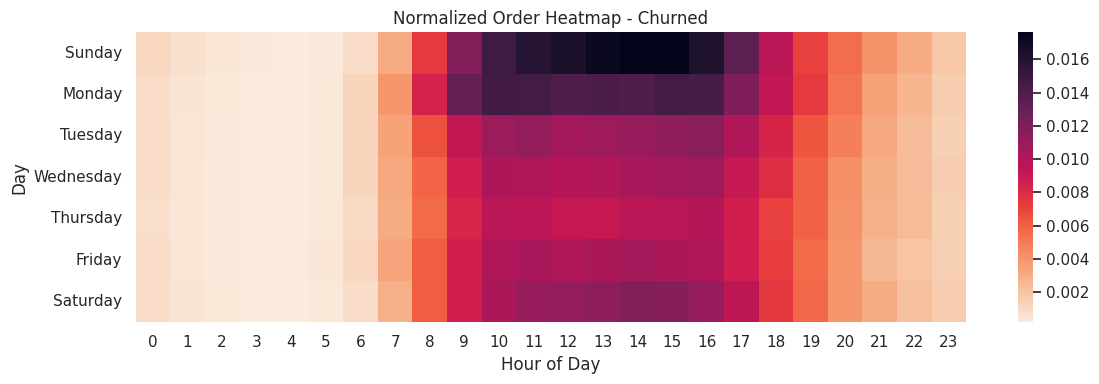

In [21]:
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_map = dict(enumerate(day_order))

segment_heatmap = (
    segment_txn[["segment", "order_id", "order_dow", "order_hour_of_day"]]
    .drop_duplicates()
    .assign(day_name=lambda d: d["order_dow"].map(day_map))
    .groupby(["segment", "day_name", "order_hour_of_day"], observed=False)
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
)

for seg in segment_heatmap["segment"].dropna().unique():
    subset = segment_heatmap[segment_heatmap["segment"] == seg]

    pivot = (
        subset.pivot_table(
            index="day_name",
            columns="order_hour_of_day",
            values="order_count",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(day_order)
        .reindex(columns=range(24), fill_value=0)
    )

    # 🔥 normalize
    pivot = pivot / pivot.values.sum()

    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot, cmap="rocket_r")

    plt.title(f"Normalized Order Heatmap - {seg}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Day")
    plt.tight_layout()
    plt.show()

## Peak Hour Detection

เป้าหมาย

หาให้ได้ว่า: “แต่ละ segment peak ช่วงไหน”

In [22]:
peak_hours = (
    segment_heatmap
    .groupby(["segment", "order_hour_of_day"])
    .agg(total_orders=("order_count", "sum"))
    .reset_index()
)

# normalize ต่อ segment
peak_hours["normalized"] = (
    peak_hours.groupby("segment")["total_orders"]
    .transform(lambda x: x / x.sum())
)

# หา top hour
top_peak = (
    peak_hours
    .sort_values(["segment", "normalized"], ascending=[True, False])
    .groupby("segment")
    .head(3)
)

top_peak

,segment,order_hour_of_day,total_orders,normalized
10,Whales,10,101532,0.089413
9,Whales,9,95564,0.084158
11,Whales,11,95437,0.084046
39,Regulars,15,128644,0.083467
35,Regulars,11,128150,0.083146
38,Regulars,14,127725,0.082871
63,Churned,15,46082,0.085642
62,Churned,14,45621,0.084785
64,Churned,16,45146,0.083902


## Difference Heatmap

เป้าหมาย

ดูว่า “Whale ต่างจาก Regular ตรงไหน”

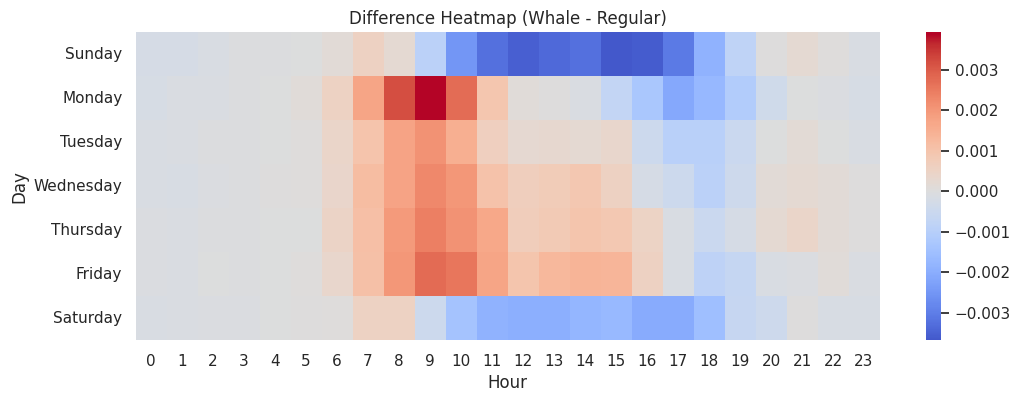

In [23]:
def create_pivot(df, segment):
    subset = df[df["segment"] == segment]

    pivot = (
        subset.pivot_table(
            index="day_name",
            columns="order_hour_of_day",
            values="order_count",
            fill_value=0,
        )
        .reindex(day_order)
        .reindex(columns=range(24), fill_value=0)
    )

    return pivot / pivot.values.sum()  # normalize

whale_pivot = create_pivot(segment_heatmap, "Whales")
regular_pivot = create_pivot(segment_heatmap, "Regulars")

diff = whale_pivot - regular_pivot


#Plotting Visualization
plt.figure(figsize=(12,4))
sns.heatmap(diff, cmap="coolwarm", center=0)

plt.title("Difference Heatmap (Whale - Regular)")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

# 📊 วิเคราะห์พฤติกรรมลูกค้า: Whales vs Regulars

## 🔥 สรุปภาพรวม (Executive Summary)

- **Whales (ลูกค้ารายใหญ่)**  
  - Peak: **07:00–10:00**
  - พฤติกรรม: ซื้อเร็ว ตัดสินใจไว เป็นช่วง (burst)

- **Regulars (ลูกค้าทั่วไป)**  
  - Peak: **10:00–15:00**
  - พฤติกรรม: ค่อย ๆ ดู ค่อย ๆ ซื้อ กระจายทั้งวัน

> 💡 Insight สำคัญ:  
> **“เวลา (Time of Day) แยกพฤติกรรมลูกค้าได้ชัดกว่าประเภทลูกค้า”**

---

## 🐋 พฤติกรรมของ Whales

### 📈 Pattern หลัก
- มีจุดพีคแรงช่วง **08:00–10:00**
- **Monday เช้า** สูงที่สุด
- หลัง **11:00** ลดลงต่อเนื่อง

### 🧠 ตีความพฤติกรรม
- มี **intent ชัดเจน** ก่อนเข้ามา
- เข้า → ซื้อ → ออก (ไม่เสียเวลานาน)
- มักเป็นการซื้อแบบวางแผนไว้แล้ว

---

## 🧑‍🤝‍🧑 พฤติกรรมของ Regulars

### 📈 Pattern หลัก
- พีคช่วง **10:00–15:00**
- มี activity กระจายทั้งวัน
- เย็นยังมี traffic ต่อ

### 🧠 ตีความพฤติกรรม
- ใช้เวลา **browse / เปรียบเทียบ**
- ตัดสินใจช้ากว่า
- เป็นกลุ่มที่สร้าง **volume หลักของระบบ**

---

## ⚔️ เปรียบเทียบ (Difference: Whale - Regular)

### 🔴 ช่วงที่ Whales เด่นกว่า
- **07:00–10:00**
- โดยเฉพาะ **Monday**

👉 แปล:
- เป็นช่วงที่ลูกค้ารายใหญ่ active สูง
- เหมาะกับการขายของมูลค่าสูง

---

### 🔵 ช่วงที่ Regulars เด่นกว่า
- **11:00–16:00**
- โดยเฉพาะ **Weekend**

👉 แปล:
- เป็นช่วง browsing / discovery
- ลูกค้าทั่วไปเข้ามาใช้งานมาก

---

## ⏰ การแบ่งช่วงเวลา (Temporal Segmentation)

| ช่วงเวลา | กลุ่มหลัก |
|----------|----------|
| 07:00–10:00 | Whales |
| 10:00–16:00 | Regulars |
| 17:00–20:00 | ผสม |

---

## 🧠 เปรียบเทียบเชิงพฤติกรรม

| Feature | Whales | Regulars |
|--------|--------|----------|
| ความเร็วในการตัดสินใจ | สูง | ปานกลาง |
| ระยะเวลาใช้งาน | สั้น | ยาว |
| Intent | ชัดเจน | ยัง explore |
| รูปแบบการซื้อ | เป็นช่วง (burst) | ต่อเนื่อง |

---

## 🎯 แนวทางนำไปใช้ (Business Strategy)

### 1. Time-based Promotion
- **07:00–10:00**
  - เน้น: สินค้า high-value / bundle
- **10:00–16:00**
  - เน้น: discount / recommendation

---

### 2. Feature Engineering (สำหรับ ML)

สามารถสร้าง feature ได้ เช่น:

- `hour_of_day`
- `day_of_week`
- `is_morning_peak`
- `is_whale_hour`
- `user_segment`

---

### 3. Model ที่สามารถทำต่อได้

- Purchase Prediction
- Customer Segmentation
- Time-aware Recommendation System
- Revenue Forecasting

---

## 💡 Insight ระดับลึก

- **Whales = Revenue Driver**
- **Regulars = Traffic Driver**

> 🔥 Insight สำคัญ:
> ลูกค้ารายใหญ่ไม่ได้ active ทั้งวัน  
> แต่จะ active “เฉพาะช่วงเวลาที่เขาจะซื้อ”

---

## 🚀 สรุปสุดท้าย

- Whales:
  - ซื้อเร็ว
  - ซื้อช่วงเช้า
  - มูลค่าสูง

- Regulars:
  - ซื้อยาว
  - ซื้อช่วงกลางวัน
  - จำนวนเยอะ

> 🎯 Core Insight:
> **“Time = Key Feature ที่สำคัญมากใน Customer Behavior Modeling”**

### 🧠 Interpretation (Hypothesis)

- Regular users show a more **distributed activity pattern**
  across 10:00–15:00 compared to whales.

- This may suggest:
  - Longer engagement window
  - Potential browsing or delayed decision-making behavior

> ⚠️ Note:
> These are hypotheses and require validation with session-level data
> such as clickstream or time-to-purchase.

## Customer Behavior Signature

In [24]:
orders_per_customer_df = (
    segment_txn[["user_id", "segment", "order_id"]]
    .drop_duplicates(subset=["user_id", "order_id"])
    .groupby(["segment", "user_id"], observed=False)["order_id"]
    .nunique()
    .reset_index(name="orders_per_customer")
    .groupby("segment", observed=False)["orders_per_customer"]
    .agg(avg_orders_per_customer="mean", median_orders="median")
    .reset_index()
)

basket_size = (
    segment_txn.groupby(["segment", "order_id"], observed=False)
    .size()
    .rename("basket_size")
    .reset_index()
    .groupby("segment", observed=False)["basket_size"]
    .mean()
    .reset_index(name="avg_basket_size")
)

reorder_rate = (
    segment_txn.groupby("segment", observed=False)["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

peak = (
    top_peak.groupby("segment", observed=False)["order_hour_of_day"]
    .apply(lambda s: sorted(s.astype(int).tolist()))
    .reset_index(name="peak_hours")
)

signature = (
    orders_per_customer_df
    .merge(basket_size, on="segment", how="left")
    .merge(reorder_rate, on="segment", how="left")
    .merge(peak, on="segment", how="left")
    .sort_values("avg_orders_per_customer", ascending=False)
)

signature

,segment,avg_orders_per_customer,median_orders,avg_basket_size,reorder_rate,peak_hours
1,Regulars,7.474262,4.0,4.897214,0.529902,"[11, 14, 15]"
0,Whales,5.506724,0.0,3.568497,0.733831,"[9, 10, 11]"
2,Churned,2.609382,0.0,1.623173,0.453231,"[14, 15, 16]"


## Inter-order Time (ของแทน session)

In [25]:
interorder_df = (
    segment_txn[["user_id", "segment", "order_id", "order_date", "order_hour_of_day"]]
    .drop_duplicates(subset=["user_id", "order_id"])
    .copy()
)

interorder_df["order_ts"] = (
    pd.to_datetime(interorder_df["order_date"])
    + pd.to_timedelta(interorder_df["order_hour_of_day"], unit="h")
)
interorder_df = interorder_df.sort_values(["user_id", "order_ts"])
interorder_df["time_diff"] = interorder_df.groupby("user_id")["order_ts"].diff()
interorder_df["time_diff_days"] = interorder_df["time_diff"].dt.total_seconds() / 86400

interorder_df[["user_id", "segment", "order_id", "order_ts", "time_diff_days"]].head()
interorder_df_clean = interorder_df.dropna(subset=["time_diff_days"])

In [26]:
interorder_df_clean.groupby("segment")["time_diff_days"].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Whales,1115512.0,5.818399,4.787263,0.0,2.791667,4.916667,7.125000,30.958333
Regulars,1418261.0,12.810210,9.185821,0.0,5.958333,9.708333,18.875000,30.958333
Churned,474892.0,15.909302,10.252709,0.0,6.916667,13.875000,28.541667,30.958333


<Axes: xlabel='time_diff_days', ylabel='Density'>

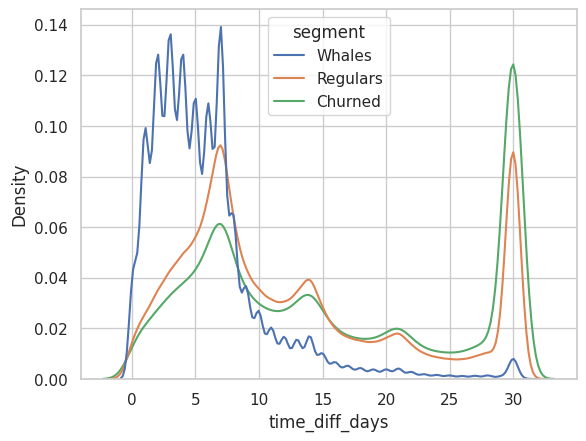

In [27]:
sns.kdeplot(
    data=interorder_df_clean,
    x="time_diff_days",
    hue="segment",
    common_norm=False
)

## 📊 Inter-order Time Analysis

Inter-order time was used as a proxy for customer engagement due to the absence of session-level data.

### Key Findings

- Whale customers exhibit significantly shorter inter-order intervals (2–6 days),
  indicating high engagement and frequent purchasing behavior.

- Regular users show a broader distribution, with both short cycles and a strong peak
  around 30 days, suggesting mixed purchasing patterns.

- Churned users are heavily concentrated around longer intervals (~30 days),
  indicating decreasing engagement before churn.

### 💡 Key Insight

An increasing inter-order interval may serve as an early signal of churn risk.

## 📊 การวิเคราะห์ช่วงเวลาระหว่างการสั่งซื้อ (Inter-order Time Analysis)

ช่วงเวลาระหว่างการสั่งซื้อ (inter-order time) ถูกนำมาใช้เป็นตัวแทน (proxy)
ของระดับการมีส่วนร่วมของลูกค้า (customer engagement)
เนื่องจากไม่มีข้อมูลระดับ session (เช่น พฤติกรรมการเข้าชมหรือการคลิก)

### 🔍 ข้อค้นพบหลัก (Key Findings)

- ลูกค้ากลุ่ม Whale มีช่วงเวลาระหว่างการสั่งซื้อที่สั้นอย่างมีนัยสำคัญ (ประมาณ 2–6 วัน)
  สะท้อนถึงความถี่ในการซื้อที่สูงและระดับการมีส่วนร่วมที่มาก

- ลูกค้ากลุ่ม Regular มีการกระจายตัวที่กว้างกว่า
  โดยมีทั้งการซื้อถี่ในระยะสั้น และมีจุดสูง (peak) ชัดเจนที่ประมาณ 30 วัน
  ซึ่งบ่งชี้ถึงรูปแบบการซื้อที่หลากหลาย

- ลูกค้าที่เลิกใช้งาน (Churned) มีแนวโน้มกระจุกตัวอยู่ในช่วงเวลาที่ยาวขึ้น (ประมาณ 30 วัน)
  สะท้อนถึงความถี่ในการซื้อที่ลดลงก่อนการเลิกใช้งาน

### 💡 Insight สำคัญ

การที่ช่วงเวลาระหว่างการสั่งซื้อเพิ่มขึ้น
อาจเป็นสัญญาณล่วงหน้าของความเสี่ยงในการเลิกใช้งาน (churn)

- ลูกค้าที่ Churn มีช่วงห่างระหว่างการสั่งซื้อ (inter-order interval) ที่ยาวกว่า
  ซึ่งบ่งชี้ถึงความถี่ในการซื้อที่ลดลงก่อนที่จะเลิกใช้งาน

- อย่างไรก็ตาม เนื่องจากไม่มีข้อมูลระดับ session (เช่น พฤติกรรมการดูสินค้า หรือการคลิก)
  จึงไม่สามารถสรุปได้ว่าพฤติกรรมดังกล่าวเกิดจาก
  การใช้เวลาตัดสินใจนานขึ้น หรือการมีส่วนร่วม (engagement) ที่ลดลง